# MSI Pipeline - Script 05: Clustering

This notebook performs dimensionality reduction and clustering on MSI data.

## Workflow
1. Highly variable feature selection (top N channels)
2. PCA: 21-25 components
3. KNN graph: 15 neighbors
4. Leiden clustering: resolution 0.3-0.6
5. UMAP: 2D embedding for visualization

## Parameters (from successful workflows)
- n_pcs: 21
- n_neighbors: 15
- leiden_resolution: 0.6
- umap_min_dist: 0.1

## Input
- Preprocessed AnnData files (optionally with Moran's I from script04)

## Output
- AnnData with clustering results
- Cluster assignments (CSV)
- UMAP coordinates (CSV)

In [1]:
import sys
from pathlib import Path
import logging

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# Add parent directory for imports
sys.path.insert(0, str(Path.cwd().parent))

from utils import clustering as msi_cluster
from utils import io as msi_io

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Plot settings
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
sc.settings.verbosity = 2

c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Compatibility patch for matplotlib.rcParams._get
# Some combinations of matplotlib/seaborn expect an internal _get method on rcParams.
# If it's missing (recent matplotlib versions), provide a safe shim that uses dict.get.
# This cell must run before any seaborn/matplotlib plotting utilities are invoked.
import types
import matplotlib as mpl

if not hasattr(mpl.rcParams, '_get'):
    def _rcparams_get(self, key, default=None):
        """Emulate the old _get behaviour using dict.get."""
        try:
            return self.get(key, default)
        except Exception:
            # Fallback: return default if anything goes wrong
            return default

    mpl.rcParams._get = types.MethodType(_rcparams_get, mpl.rcParams)

# Also ensure seaborn reads the rc params safely by calling its set_style once
try:
    import seaborn as sns
    sns.set_style('whitegrid')
except Exception:
    pass

## Configuration

In [3]:
# === CONFIGURE THESE PATHS ===

# Base data directory
BASE_DIR = Path(r"T:/Sammy Data/Third set results/")  # Path.home() / "ext_hd_sammy"
#BASE_DIR = Path.home() / "ext_hd_sammy"

# Input: Preprocessed AnnData files
INPUT_DIR = BASE_DIR / "metabolites_h5ad_processed"

# Output directories
OUTPUT_DIR = BASE_DIR / "metabolites_clustering_results"

# Clustering parameters
N_PCS = 21  # Number of principal components
N_NEIGHBORS = 15  # KNN neighbors for graph construction
LEIDEN_RESOLUTION = 0.6  # Leiden clustering resolution
UMAP_MIN_DIST = 0.1  # UMAP minimum distance

# Feature selection
USE_SPATIALLY_COHERENT = True  # Use only spatially coherent channels (from script04)
N_TOP_FEATURES = 50  # Number of top features if not using spatial filtering

# Random seed for reproducibility
RANDOM_STATE = 42

# Create output directory
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input directory: {INPUT_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"\nClustering parameters:")
print(f"  n_pcs: {N_PCS}")
print(f"  n_neighbors: {N_NEIGHBORS}")
print(f"  leiden_resolution: {LEIDEN_RESOLUTION}")

Input directory: T:\Sammy Data\Third set results\metabolites_h5ad_processed
Output directory: T:\Sammy Data\Third set results\metabolites_clustering_results

Clustering parameters:
  n_pcs: 21
  n_neighbors: 15
  leiden_resolution: 0.6


## Discover Samples

In [4]:
# Find all h5ad files
sample_files = list(INPUT_DIR.glob("*.h5ad"))
sample_ids = [f.stem for f in sample_files]

print(f"Found {len(sample_ids)} samples:")
for sid in sample_ids:
    print(f"  - {sid}")

Found 40 samples:
  - S001 ovary manual mets
  - S004 ovary manual mets
  - S005 ovary manual mets
  - S006 ovary manual mets
  - S019 ovary manual mets
  - S020 ovary manual mets
  - S022 ovary manual mets
  - S023 ovary manual mets
  - S024 ovary manual mets
  - S025 ovary manual mets
  - S026 ovary manual mets
  - S030 ovary manual mets
  - S032 ovary manual mets
  - S033 ovary manual mets
  - S034 ovary manual mets
  - S044 ovary manual mets
  - S045 ovary manual mets
  - S046 ovary manual mets
  - S047 ovary manual mets
  - SO11 ovary manual mets
  - SO14 ovary manual mets
  - SO15 ovary manual mets
  - SO36 ovary manual mets
  - SO39 ovary manual mets
  - SO40 ovary manual mets
  - SO48 ovary manual mets
  - SO50 ovary manual mets
  - SO51 ovary manual mets
  - SO52 ovary manual mets
  - SO53 ovary manual mets
  - SO54 ovary manual mets
  - SO55 ovary manual mets
  - SO56 ovary manual mets
  - SO57 ovary manual mets
  - SO58 ovary manual mets
  - SO59 ovary manual mets
  - SO64 o

## Load Sample

In [5]:
# Load first sample
if sample_files:
    sample_file = sample_files[0]
    sample_id = sample_file.stem
    
    print(f"Loading {sample_id}...")
    adata = ad.read_h5ad(sample_file)
    
    print(f"Shape: {adata.shape}")
    print(f"\n.var columns: {list(adata.var.columns)}")
    
    # Check for spatial coherence info
    if 'spatially_coherent' in adata.var.columns:
        n_coherent = adata.var['spatially_coherent'].sum()
        print(f"Spatially coherent channels: {n_coherent}")

Loading S001 ovary manual mets...
Shape: (265094, 740)

.var columns: ['channel_name', 'modality', 'mean', 'std', 'median', 'min', 'max', 'pct_nonzero', 'pct_5', 'pct_95', 'morans_i_I', 'morans_i_p', 'spatially_coherent']
Spatially coherent channels: 69


## Feature Selection

In [6]:
def select_features(adata, use_spatial=True, n_top=50):
    """Select features for clustering."""
    
    if use_spatial and 'spatially_coherent' in adata.var.columns:
        # Use spatially coherent channels
        mask = adata.var['spatially_coherent'].values
        n_selected = mask.sum()
        print(f"Using {n_selected} spatially coherent channels")
        
        if n_selected < 10:
            print(f"Warning: Only {n_selected} coherent channels, using top variance instead")
            use_spatial = False
        else:
            return adata[:, mask].copy()
    
    if not use_spatial:
        # Select by variance
        X = adata.X if not hasattr(adata.X, 'toarray') else adata.X.toarray()
        variances = np.var(X, axis=0)
        top_idx = np.argsort(variances)[-n_top:][::-1]
        
        print(f"Selected top {len(top_idx)} channels by variance")
        return adata[:, top_idx].copy()
    
    return adata.copy()

In [7]:
# Select features
adata_selected = select_features(
    adata, 
    use_spatial=USE_SPATIALLY_COHERENT, 
    n_top=N_TOP_FEATURES
)

print(f"\nSelected data shape: {adata_selected.shape}")

Using 69 spatially coherent channels

Selected data shape: (265094, 69)


## PCA

In [8]:
# Run PCA
print(f"Running PCA with {N_PCS} components...")

# Adjust n_pcs if fewer features than requested
n_pcs = min(N_PCS, adata_selected.n_vars - 1, adata_selected.n_obs - 1)

sc.tl.pca(adata_selected, n_comps=n_pcs, random_state=RANDOM_STATE)

print(f"PCA complete: {n_pcs} components")

Running PCA with 21 components...
computing PCA
    with n_comps=21
    finished (0:00:01)
PCA complete: 21 components


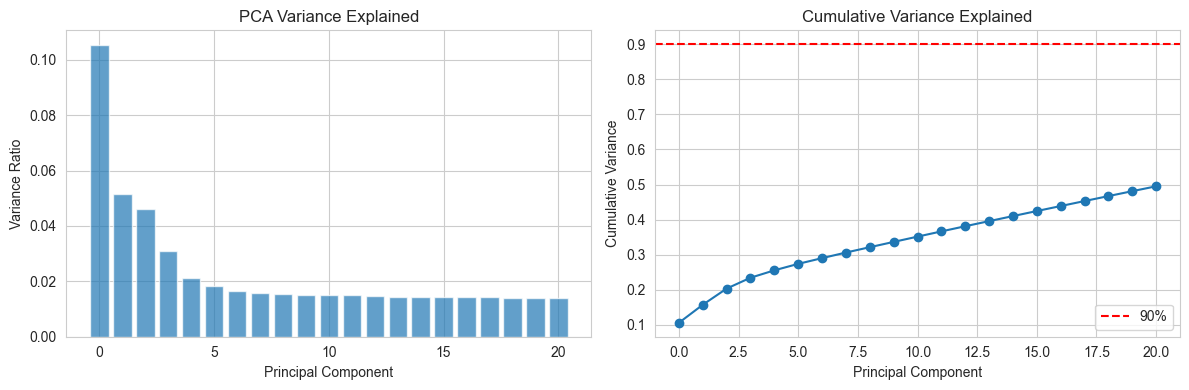

Variance explained by 21 PCs: 49.5%


In [9]:
# Visualize PCA variance explained
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Variance ratio
ax = axes[0]
variance_ratio = adata_selected.uns['pca']['variance_ratio']
ax.bar(range(len(variance_ratio)), variance_ratio, alpha=0.7)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Ratio')
ax.set_title('PCA Variance Explained')

# Cumulative variance
ax = axes[1]
cumulative = np.cumsum(variance_ratio)
ax.plot(range(len(cumulative)), cumulative, 'o-')
ax.axhline(0.9, color='r', linestyle='--', label='90%')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Cumulative Variance')
ax.set_title('Cumulative Variance Explained')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{sample_id}_pca_variance.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Variance explained by {n_pcs} PCs: {cumulative[-1]:.1%}")

## Neighbor Graph & Clustering

In [10]:
# Build neighbor graph
print(f"Building neighbor graph (k={N_NEIGHBORS})...")
sc.pp.neighbors(adata_selected, n_neighbors=N_NEIGHBORS, n_pcs=n_pcs, 
                random_state=RANDOM_STATE)

# Leiden clustering
print(f"Running Leiden clustering (resolution={LEIDEN_RESOLUTION})...")
sc.tl.leiden(adata_selected, resolution=LEIDEN_RESOLUTION, random_state=RANDOM_STATE)

# Count clusters
n_clusters = adata_selected.obs['leiden'].nunique()
print(f"Found {n_clusters} clusters")

Building neighbor graph (k=15)...
computing neighbors
    using 'X_pca' with n_pcs = 21
    finished (0:00:19)
Running Leiden clustering (resolution=0.6)...
running Leiden clustering
    finished (0:09:10)
Found 9 clusters


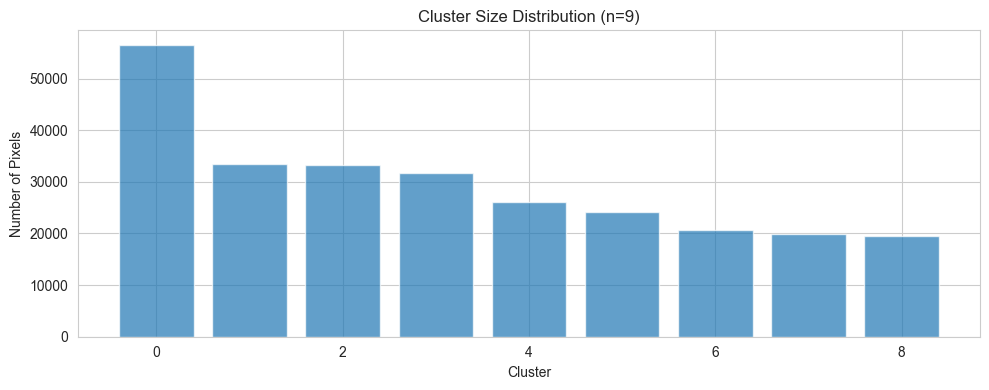


Cluster sizes:
0    56494
1    33409
2    33286
3    31616
4    26029
5    24171
6    20671
7    19839
8    19579
Name: leiden, dtype: int64


In [11]:
# Cluster size distribution
cluster_sizes = adata_selected.obs['leiden'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cluster_sizes.index.astype(int), cluster_sizes.values, alpha=0.7)
ax.set_xlabel('Cluster')
ax.set_ylabel('Number of Pixels')
ax.set_title(f'Cluster Size Distribution (n={n_clusters})')

plt.tight_layout()
plt.show()

print("\nCluster sizes:")
print(cluster_sizes)

## UMAP

In [12]:
# Run UMAP
print(f"Computing UMAP (min_dist={UMAP_MIN_DIST})...")
sc.tl.umap(adata_selected, min_dist=UMAP_MIN_DIST, random_state=RANDOM_STATE)

print("UMAP complete")

Computing UMAP (min_dist=0.1)...
computing UMAP
    finished (0:01:51)
UMAP complete


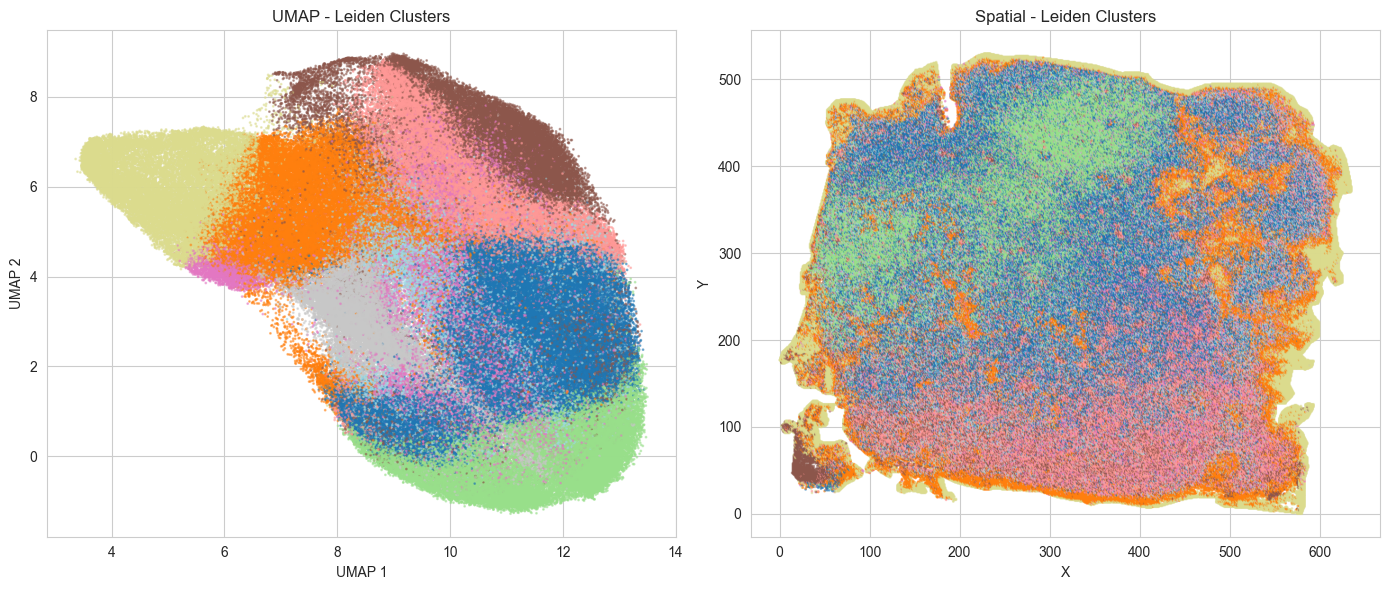

In [13]:
# Visualize UMAP colored by cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# UMAP with clusters
ax = axes[0]
scatter = ax.scatter(
    adata_selected.obsm['X_umap'][:, 0],
    adata_selected.obsm['X_umap'][:, 1],
    c=adata_selected.obs['leiden'].astype(int),
    cmap='tab20',
    s=1,
    alpha=0.5
)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP - Leiden Clusters')

# Spatial plot with clusters
ax = axes[1]
coords = adata_selected.obsm['spatial']
scatter = ax.scatter(
    coords[:, 0],
    coords[:, 1],
    c=adata_selected.obs['leiden'].astype(int),
    cmap='tab20',
    s=1,
    alpha=0.5
)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Spatial - Leiden Clusters')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{sample_id}_clustering.png", dpi=150, bbox_inches='tight')
plt.show()

## Cluster Marker Analysis

In [14]:
# Find marker channels for each cluster
print("Finding cluster markers...")
sc.tl.rank_genes_groups(adata_selected, 'leiden', method='wilcoxon')

# Show top markers per cluster
print("\nTop 5 markers per cluster:")
markers = sc.get.rank_genes_groups_df(adata_selected, group=None)

for cluster in sorted(adata_selected.obs['leiden'].unique().astype(int)):
    cluster_markers = markers[markers['group'] == str(cluster)].head(5)
    marker_names = cluster_markers['names'].tolist()
    print(f"  Cluster {cluster}: {marker_names}")

Finding cluster markers...
ranking genes
    finished (0:00:18)

Top 5 markers per cluster:
  Cluster 0: ['_R_-Lipoic_acid', '78_9597_m_z___15_ppm', '355_04_m_z___15_ppm', '224_0694_m_z___15_ppm', '419_2553_m_z___15_ppm']
  Cluster 1: ['254_9738_m_z___15_ppm', '256_9729_m_z___15_ppm', 'Stearic_acid', '439_3319_m_z___15_ppm', '427_2952_m_z___15_ppm']
  Cluster 2: ['_R_-Lipoic_acid', '355_04_m_z___15_ppm', 'Isorhamnetin', '299_0529_m_z___15_ppm', '78_9597_m_z___15_ppm']
  Cluster 3: ['265_1474_m_z___15_ppm', '237_0334_m_z___15_ppm', '321_2101_m_z___15_ppm', '281_1422_m_z___15_ppm', '96_9599_m_z___15_ppm']
  Cluster 4: ['239_0292_m_z___15_ppm', '265_1474_m_z___15_ppm', '237_0334_m_z___15_ppm', '321_2101_m_z___15_ppm', '96_9599_m_z___15_ppm']
  Cluster 5: ['Glucaric_acid', '277_1796_m_z___15_ppm', '227_0445_m_z___15_ppm', 'Taurine', '203_0457_m_z___15_ppm']
  Cluster 6: ['Cytosine', '78_9597_m_z___15_ppm', 'Succinic_acid', 'Guanine', 'Adenine']
  Cluster 7: ['256_9729_m_z___15_ppm', '254_9

c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:417: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:418: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:417: RuntimeWarning: invalid value encountered in true_divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:420: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:417: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Apps\

c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\plotting\_anndata.py:2414: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  obs_tidy.index.value_counts(sort=False).iteritems()


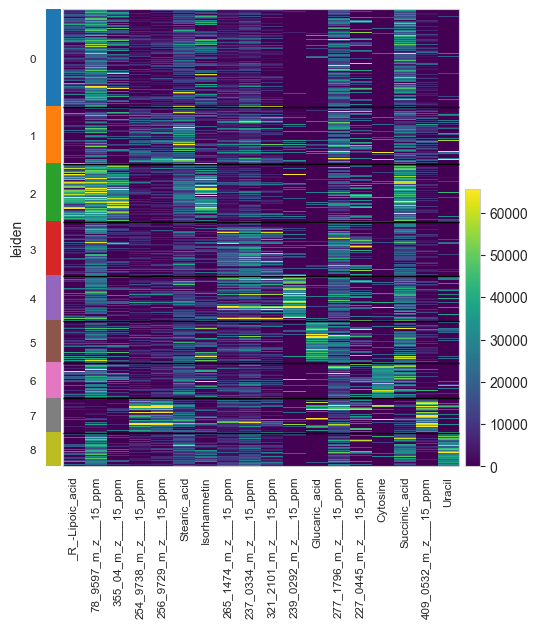

In [15]:
# Heatmap of top markers
n_top_markers = 3
top_markers = []
for cluster in sorted(adata_selected.obs['leiden'].unique().astype(int)):
    cluster_markers = markers[markers['group'] == str(cluster)].head(n_top_markers)
    top_markers.extend(cluster_markers['names'].tolist())

# Remove duplicates while preserving order
top_markers = list(dict.fromkeys(top_markers))

if len(top_markers) > 0:
    sc.pl.heatmap(
        adata_selected, 
        var_names=top_markers[:20],  # Limit to 20 for readability
        groupby='leiden',
        cmap='viridis',
        show_gene_labels=True,
        save=f'_{sample_id}_markers.png'
    )

## Save Results

In [16]:
# Transfer clustering results back to original adata
# (matching indices)
adata.obs['leiden'] = adata_selected.obs['leiden']
adata.obsm['X_pca'] = adata_selected.obsm['X_pca']
adata.obsm['X_umap'] = adata_selected.obsm['X_umap']
adata.uns['pca'] = adata_selected.uns['pca']
adata.uns['neighbors'] = adata_selected.uns['neighbors']
adata.uns['umap'] = adata_selected.uns['umap']
adata.uns['leiden'] = adata_selected.uns['leiden']

# Store clustering parameters
adata.uns['clustering_params'] = {
    'n_pcs': n_pcs,
    'n_neighbors': N_NEIGHBORS,
    'leiden_resolution': LEIDEN_RESOLUTION,
    'umap_min_dist': UMAP_MIN_DIST,
    'random_state': RANDOM_STATE,
    'n_features_used': adata_selected.n_vars,
}

# Save updated AnnData
adata.write_h5ad(sample_file, compression='gzip')
print(f"Updated AnnData saved")

Updated AnnData saved


In [17]:
# Save clustering results as CSV
saved_files = msi_cluster.save_clustering_results(
    adata,
    output_dir=str(OUTPUT_DIR),
    sample_id=sample_id,
    save_umap=True,
    save_clusters=True
)

print(f"Saved files:")
for f in saved_files:
    print(f"  - {f}")

INFO:utils.clustering:Saved clusters to T:\Sammy Data\Third set results\metabolites_clustering_results\S001 ovary manual mets_clusters.csv
INFO:utils.clustering:Saved UMAP to T:\Sammy Data\Third set results\metabolites_clustering_results\S001 ovary manual mets_umap.csv


Saved files:
  - T:\Sammy Data\Third set results\metabolites_clustering_results\S001 ovary manual mets_clusters.csv
  - T:\Sammy Data\Third set results\metabolites_clustering_results\S001 ovary manual mets_umap.csv


In [18]:
# Save marker genes
markers_path = OUTPUT_DIR / f"{sample_id}_markers.csv"
markers.to_csv(markers_path, index=False)
print(f"Markers saved to {markers_path}")

Markers saved to T:\Sammy Data\Third set results\metabolites_clustering_results\S001 ovary manual mets_markers.csv


## Batch Process All Samples

In [19]:
def process_sample_clustering(input_path, output_dir, n_pcs, n_neighbors, 
                              resolution, min_dist, use_spatial, n_top_features,
                              random_state=42):
    """Process a single sample through clustering pipeline."""
    sample_id = input_path.stem
    logger.info(f"Processing {sample_id}...")
    
    # Load
    adata = ad.read_h5ad(input_path)
    
    # Feature selection
    adata_sel = select_features(adata, use_spatial=use_spatial, n_top=n_top_features)
    
    # Adjust n_pcs
    n_pcs_adj = min(n_pcs, adata_sel.n_vars - 1, adata_sel.n_obs - 1)
    
    # PCA
    sc.tl.pca(adata_sel, n_comps=n_pcs_adj, random_state=random_state)
    
    # Neighbors & clustering
    sc.pp.neighbors(adata_sel, n_neighbors=n_neighbors, n_pcs=n_pcs_adj, 
                    random_state=random_state)
    sc.tl.leiden(adata_sel, resolution=resolution, random_state=random_state)
    
    # UMAP
    sc.tl.umap(adata_sel, min_dist=min_dist, random_state=random_state)
    
    # Find markers
    sc.tl.rank_genes_groups(adata_sel, 'leiden', method='wilcoxon')
    markers = sc.get.rank_genes_groups_df(adata_sel, group=None)
    
    # Transfer to original adata
    adata.obs['leiden'] = adata_sel.obs['leiden']
    adata.obsm['X_pca'] = adata_sel.obsm['X_pca']
    adata.obsm['X_umap'] = adata_sel.obsm['X_umap']
    adata.uns['pca'] = adata_sel.uns['pca']
    adata.uns['clustering_params'] = {
        'n_pcs': n_pcs_adj,
        'n_neighbors': n_neighbors,
        'resolution': resolution,
    }
    
    # Save
    adata.write_h5ad(input_path, compression='gzip')
    msi_cluster.save_clustering_results(adata, str(output_dir), sample_id)
    markers.to_csv(output_dir / f"{sample_id}_markers.csv", index=False)
    
    n_clusters = adata.obs['leiden'].nunique()
    
    return {
        'sample_id': sample_id,
        'n_clusters': n_clusters,
        'n_features': adata_sel.n_vars,
        'n_pcs': n_pcs_adj,
        'status': 'success'
    }

In [20]:
# Process all samples
all_results = []

for sample_file in sample_files:
    try:
        result = process_sample_clustering(
            input_path=sample_file,
            output_dir=OUTPUT_DIR,
            n_pcs=N_PCS,
            n_neighbors=N_NEIGHBORS,
            resolution=LEIDEN_RESOLUTION,
            min_dist=UMAP_MIN_DIST,
            use_spatial=USE_SPATIALLY_COHERENT,
            n_top_features=N_TOP_FEATURES,
            random_state=RANDOM_STATE
        )
        all_results.append(result)
    except Exception as e:
        logger.error(f"Error processing {sample_file.stem}: {e}")
        all_results.append({
            'sample_id': sample_file.stem,
            'status': 'error',
            'error': str(e)
        })

# Summary
summary_df = pd.DataFrame(all_results)
summary_df.to_csv(OUTPUT_DIR / "clustering_summary.csv", index=False)
print("\nClustering Summary:")
print(summary_df)

INFO:__main__:Processing S001 ovary manual mets...


Using 69 spatially coherent channels
computing PCA
    with n_comps=21
    finished (0:00:01)
computing neighbors
    using 'X_pca' with n_pcs = 21
    finished (0:00:07)
running Leiden clustering
    finished (0:08:37)
computing UMAP
    finished (0:01:49)
ranking genes
    finished (0:00:17)


c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:417: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:418: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:417: RuntimeWarning: invalid value encountered in true_divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:420: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:417: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Apps\

Using 109 spatially coherent channels
computing PCA
    with n_comps=21
    finished (0:00:02)
computing neighbors
    using 'X_pca' with n_pcs = 21
    finished (0:00:04)
running Leiden clustering
    finished (0:01:23)
computing UMAP
    finished (0:00:58)
ranking genes
    finished (0:00:10)


c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:417: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:418: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:417: RuntimeWarning: invalid value encountered in true_divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:420: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:417: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Apps\

...

Using 49 spatially coherent channels
computing PCA
    with n_comps=21
    finished (0:00:00)
computing neighbors
    using data matrix X directly
    finished (0:00:03)
running Leiden clustering
    finished (0:00:38)
computing UMAP
    finished (0:00:39)
ranking genes
    finished (0:00:06)


c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:417: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:418: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:417: RuntimeWarning: invalid value encountered in true_divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:420: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(
c:\Apps\miniconda3\envs\maitra_spatial\lib\site-packages\scanpy\tools\_rank_genes_groups.py:417: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Apps\

Using 109 spatially coherent channels
computing PCA
    with n_comps=21


ERROR:__main__:Error processing SO40 ovary manual mets: Unable to allocate 98.0 MiB for an array with shape (117798, 109) and data type float64
INFO:__main__:Processing SO48 ovary manual mets...
ERROR:__main__:Error processing SO48 ovary manual mets: Unable to allocate 696. MiB for an array with shape (124131, 735) and data type float64
INFO:__main__:Processing SO50 ovary manual mets...
ERROR:__main__:Error processing SO50 ovary manual mets: Unable to allocate 1.70 GiB for an array with shape (309676, 737) and data type float64
INFO:__main__:Processing SO51 ovary manual mets...
ERROR:__main__:Error processing SO51 ovary manual mets: Unable to allocate 1022. MiB for an array with shape (181178, 739) and data type float64
INFO:__main__:Processing SO52 ovary manual mets...
ERROR:__main__:Error processing SO52 ovary manual mets: Unable to allocate 674. MiB for an array with shape (118524, 745) and data type float64
INFO:__main__:Processing SO53 ovary manual mets...
ERROR:__main__:Error pro


Clustering Summary:
                 sample_id  n_clusters  n_features  n_pcs   status  \
0   S001 ovary manual mets         9.0        69.0   21.0  success   
1   S004 ovary manual mets        10.0       109.0   21.0  success   
2   S005 ovary manual mets         7.0        83.0   21.0  success   
3   S006 ovary manual mets        20.0        82.0   21.0  success   
4   S019 ovary manual mets         7.0        98.0   21.0  success   
5   S020 ovary manual mets         8.0       109.0   21.0  success   
6   S022 ovary manual mets        23.0        80.0   21.0  success   
7   S023 ovary manual mets        17.0        86.0   21.0  success   
8   S024 ovary manual mets         8.0        86.0   21.0  success   
9   S025 ovary manual mets         9.0        87.0   21.0  success   
10  S026 ovary manual mets         8.0        56.0   21.0  success   
11  S030 ovary manual mets        23.0        58.0   21.0  success   
12  S032 ovary manual mets        14.0        67.0   21.0  success   